This notebook showcases the current status of this cross correlation module. It started out as a bundle of scripts
that was then combined for reusability. This work is ongoing and there are many warts.

In [1]:
import xcorr # import name not final
import multiprocessing
from obspy.clients.filesystem.sds import Client

# Generate input files (h5)
The input to the actual cross-correlation is a h5 file containing waveforms and metadata.

## Input phases
The starting point is a list of event phases. The list in this example was generated using `xcorr.io.seiscomp_db_to_input`, but other sources 
can be implemented easily. Not all data in this table is necessary for cross correlation, but it is useful for outputting event lists etc

In [2]:
phase_data_file = "./hverahlid_phase_info.csv"
phase_data = xcorr.io.read_phase_info(phase_data_file)
ext_phase_data = xcorr.io.enhance_phase_info(phase_data, pre_pad=30, post_pad=30) # add pre/post pad and remove duplicate S phases

In [3]:
phase_data.head()

,EventID,event_time,event_latitude,event_longitude,event_depth,pick_time,network,station,location,channel,phase,event_number,offset,pre_pad,post_pad,starttime,endtime,pick_offset
0,Origin.NLL.2016-12-09T004844.493416,2016-12-09T00:48:44.493416Z,64.010141,-21.340052,2.674531,2016-12-09T00:48:46.994600Z,SI,BJA,00,HHZ,P,1,2.501184,30,30,2016-12-09T00:48:14.493416Z,2016-12-09T00:49:14.493416Z,32.501184
1,Origin.NLL.2016-12-09T004844.493416,2016-12-09T00:48:44.493416Z,64.010141,-21.340052,2.674531,2016-12-09T00:48:46.453600Z,ON,HUMLI,00,HHZ,P,1,1.960184,30,30,2016-12-09T00:48:14.493416Z,2016-12-09T00:49:14.493416Z,31.960184
2,Origin.NLL.2016-12-09T004844.493416,2016-12-09T00:48:44.493416Z,64.010141,-21.340052,2.674531,2016-12-09T00:48:47.403600Z,ON,HUMLI,00,HHE,S,1,2.910184,30,30,2016-12-09T00:48:14.493416Z,2016-12-09T00:49:14.493416Z,32.910184
3,Origin.NLL.2016-12-09T004844.493416,2016-12-09T00:48:44.493416Z,64.010141,-21.340052,2.674531,2016-12-09T00:48:45.767600Z,ON,HVH,00,HHZ,P,1,1.274184,30,30,2016-12-09T00:48:14.493416Z,2016-12-09T00:49:14.493416Z,31.274184
4,Origin.NLL.2016-12-09T004844.493416,2016-12-09T00:48:44.493416Z,64.010141,-21.340052,2.674531,2016-12-09T00:48:46.375600Z,ON,HVH,00,HHE,S,1,1.882184,30,30,2016-12-09T00:48:14.493416Z,2016-12-09T00:49:14.493416Z,31.882184


In [4]:
sampling_rate = 100

This notebook uses SeisComP SDS data structure but this can be expanded by extending `io.WaveformSource`

In [5]:
archive = Client("/nfs/archive")

Generate a list of jobs to be processed. This is a bit awkward at the moment. This processing step only creates the h5 files
that are used as input to the CC step. `generate_jobs` returns a list of dicts, but as input to `pool.starmap` it is turned 
into a list of tuples. The output is written to different h5 files to ensure concurrency when running in parallel, but the plan
was to combine the resulting files into one for a more portable dataset

In [6]:
output_dir = "./poc_h5"

In [7]:
jobs = xcorr.io.generate_jobs(sampling_rate, ext_phase_data, archive, temp_dir=output_dir)

In [8]:
job_star = [(job["station"], job["channel"], job["sampling_rate"], job["phase_info"], job["temp_name"], job["datasource"], job["progressbar"]) for job in jobs]

In [9]:
job_star_ = job_star[:6] # proof of concept

In [10]:
%%time 
# single channel
xcorr.io.process_channel(*job_star[0])

processing BJA.HHZ at 100 sps
CPU times: user 5.08 s, sys: 3.33 s, total: 8.41 s
Wall time: 32.2 s


707

In [11]:
%%time 
# single channel in parallel
with multiprocessing.Pool(8) as pool:
    pool.starmap(xcorr.io.process_channel, job_star_)

processing BJA.HHZ at 100 sps
processing HUMLI.HHZ at 100 sps
processing HUMLI.HHE at 100 sps
processing HUMLI.HHN at 100 sps
processing HVH.HHZ at 100 sps
processing HVH.HHE at 100 sps
skipping HUMLI.HHE trace with 8643 samples
skipping HUMLI.HHN trace with 8643 samples
skipping HUMLI.HHZ trace with 8643 samples
skipping HUMLI.HHE trace with 11594 samples
skipping HUMLI.HHN trace with 11844 samples
skipping HUMLI.HHZ trace with 11819 samples
CPU times: user 1.1 s, sys: 191 ms, total: 1.29 s
Wall time: 5min 4s


In [12]:
! ls -lh poc_h5

total 496M
-rw-r--r-- 1 rm domain users 17M May 29 15:56 temp_BJA_HHZ.h5
-rw-r--r-- 1 rm domain users 70M May 29 16:01 temp_HUMLI_HHE.h5
-rw-r--r-- 1 rm domain users 70M May 29 16:01 temp_HUMLI_HHN.h5
-rw-r--r-- 1 rm domain users 78M May 29  2026 temp_HUMLI_HHZ.h5
-rw-r--r-- 1 rm domain users 40M May 29 15:59 temp_HVH_HHE.h5
-rw-r--r-- 1 rm domain users 61M May 29 16:00 temp_HVH_HHZ.h5


# Cross correlate

In [13]:
from pathlib import Path

Preprocessing parameters. Need to write a full explanation but see `processing.crosscorrelation.preprocess` for how these are used,
the code is very straightforward

In [14]:
crop_1 = [4, 10]
taper = .1

params = {
    "P": {
        "crop_2": [.5, .5],
        "prefilt": [2.0, 20.0],
    },
    "S": {
        "crop_2": [.25, 1.0],
        "prefilt": [2.0, 16.0],
    }
}

In [15]:
from tqdm import tqdm

This loop should be encapsulated in a function somewhere in the module, but for now it contains the full CC logic

In [16]:
corrs_dict = {}
corrs = []

In [17]:
%%time
h5_dir = "./poc_h5" # h5 from previous step
csv_dir = Path("./csv_out_poc/") # output dir for final csv files
datafiles = list(Path(h5_dir).glob("*.h5"))
skipped = [] # debug variable

for h5_file in tqdm(datafiles):
    split = h5_file.name.split("_")
    station = split[1]
    channel = split[2].split(".")[0]

    # read the data into a WaveformData instance, some features of this class shown below
    wd = xcorr.io.read_waveforms_h5(station=station, channel=channel, file_path=str(h5_file), target_samples=5999)
    if wd.count < 2: # too little data
        skipped.append(h5_file)
        continue
        
    filter_options = params[wd.phase]
    crop_2 = filter_options["crop_2"]
    prefilt = filter_options["prefilt"]

    # preprocess step, preprocessed data is also stored in a WaveformData instance, should maybe be a separate class? TODO
    pp_wd = xcorr.batch_preprocess(wd, crop_1=crop_1, crop_2=crop_2, prefilt=prefilt, taper=taper)

    # transform into frequency space: type is FrequencyDomain
    freq_data = xcorr.fft_waveforms(pp_wd)

    # actual CC step, type is CorrelationData. multiprocess function
    corr_data = xcorr.frequency_domain_xcorr(freq_data, n_procs=6)
    
    csv_filename = csv_dir / f"{station}_{channel}.csv"
    xcorr.io.to_csv(corr_data, filename=csv_filename, station=station, phase=wd.phase, min_C=0.0, max_dt=100)

    # for debug
    corrs_dict[station] = corr_data
    corrs.append(corr_data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:01<00:00, 10.23s/it]

CPU times: user 27.7 s, sys: 2.1 s, total: 29.8 s
Wall time: 1min 1s


# WaveformData

plot waveform data before preprocessing

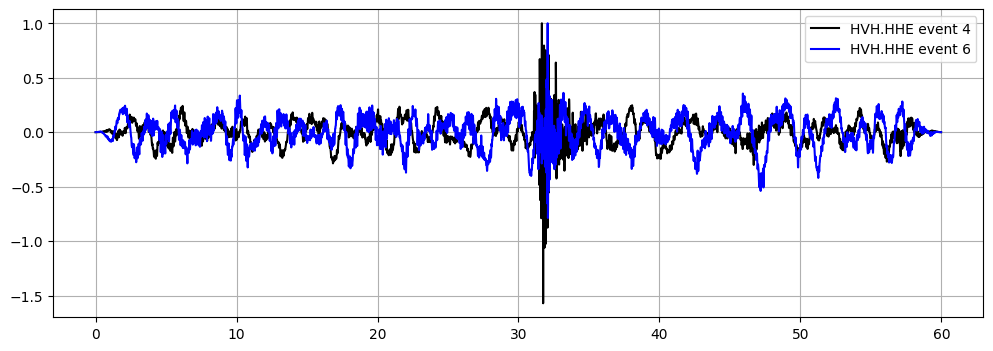

In [18]:
wd.plot_pair(4, 6)

After preprocessing

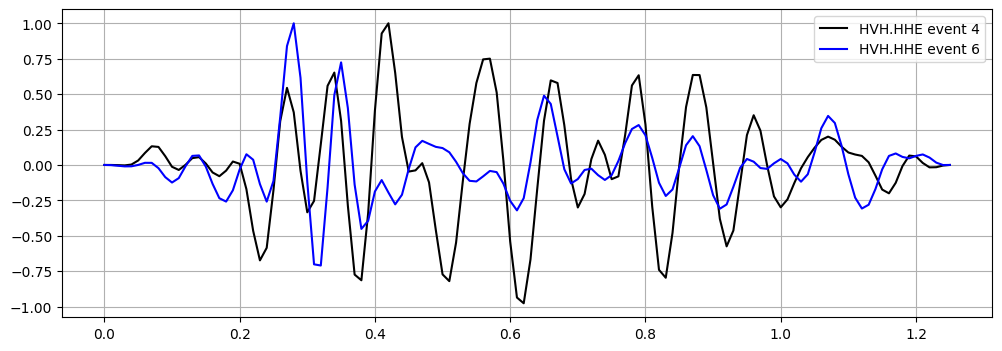

In [19]:
pp_wd.plot_pair(4, 6)

# CorrelationData

In [20]:
corrs # TODO add more data to repr

[CorrelationData(count=707),
 CorrelationData(count=1655),
 CorrelationData(count=1485),
 CorrelationData(count=1483),
 CorrelationData(count=1300),
 CorrelationData(count=855)]

In [21]:
c = corrs[-1]

has all matrix data

In [22]:
c.lag_time

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.06662179,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.52425824,  0.52289439,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.22893411, -0.28367495, -0.7095385 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.22851634,  0.16106113, -0.21630976, ..., -0.02777356,
         0.        ,  0.        ],
       [ 0.09672498,  0.03275383,  0.307936  , ..., -0.2513934 ,
        -0.13233299,  0.        ]], shape=(855, 855))

In [23]:
c.coefficient # cc coefficient
c.event_ids # event ID as defined in the original phase input
c.lag_time # final lag time output to csv
c.tt_lag_time # lag time due to travel time (outside CC window)
_ = c.cc_lag_time # lag time due to CC (inside CC window), final lag time = tt_lag_time + cc_lag_time

# Outputs
Data for every phase is saved to csv. These can then be combined into dt.cc using `io.csv_to_dtcc`

In [24]:
! ls -lh csv_out_poc

total 168M
-rw-r--r-- 1 rm domain users 8.0M May 29 16:01 BJA_HHZ.csv
-rw-r--r-- 1 rm domain users  38M May 29 16:01 HUMLI_HHE.csv
-rw-r--r-- 1 rm domain users  38M May 29 16:02 HUMLI_HHN.csv
-rw-r--r-- 1 rm domain users  47M May 29 16:01 HUMLI_HHZ.csv
-rw-r--r-- 1 rm domain users  12M May 29  2026 HVH_HHE.csv
-rw-r--r-- 1 rm domain users  27M May 29 16:02 HVH_HHZ.csv


In [25]:
! head -5 csv_out_poc/HUMLI_HHE.csv

evt1,evt2,coeff,dtcc,station,phase
1,2,0.832540,0.238747,HUMLI,S
1,3,0.587557,-0.171656,HUMLI,S
1,4,0.726735,-0.023846,HUMLI,S
1,5,0.811711,-0.101765,HUMLI,S


# Growclust
output the event list ready for Growclust

In [26]:
xcorr.io.output_growclust_evtlist(ext_phase_data, "251020_hverahlid_growclust_input.lst")

# Other datasources
To use this with non-seiscomp data sources, two things are needed:
1. something to make the input file with phase data
2. a `WaveformSource` implementation to read the waveforms